RESTAURANT CHAINS ANALYSIS

Number of Restaurant Chains: 734

Top 10 Restaurant Chains:
Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64

Top Chains by Number of Outlets:
     Restaurant Chain  Average Rating  Average Votes  Number of Outlets
122   Cafe Coffee Day        2.419277      29.253012                 83
220    Domino's Pizza        2.740506      84.088608                 79
618            Subway        2.907937      97.206349                 63
281  Green Chick Chop        2.672549      18.901961                 51
408        McDonald's        3.339583     110.229167                 48
363         Keventers        2.870588      37.147059                 34
507         Pizza Hut        3.320000     165.366667                 30
271             Giani        2

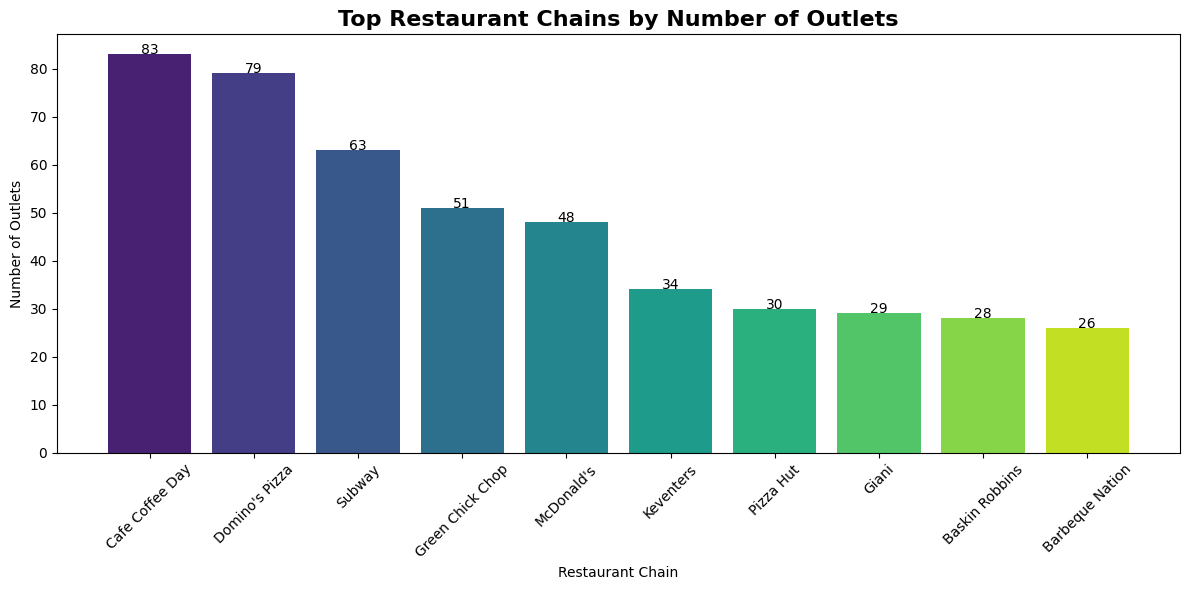

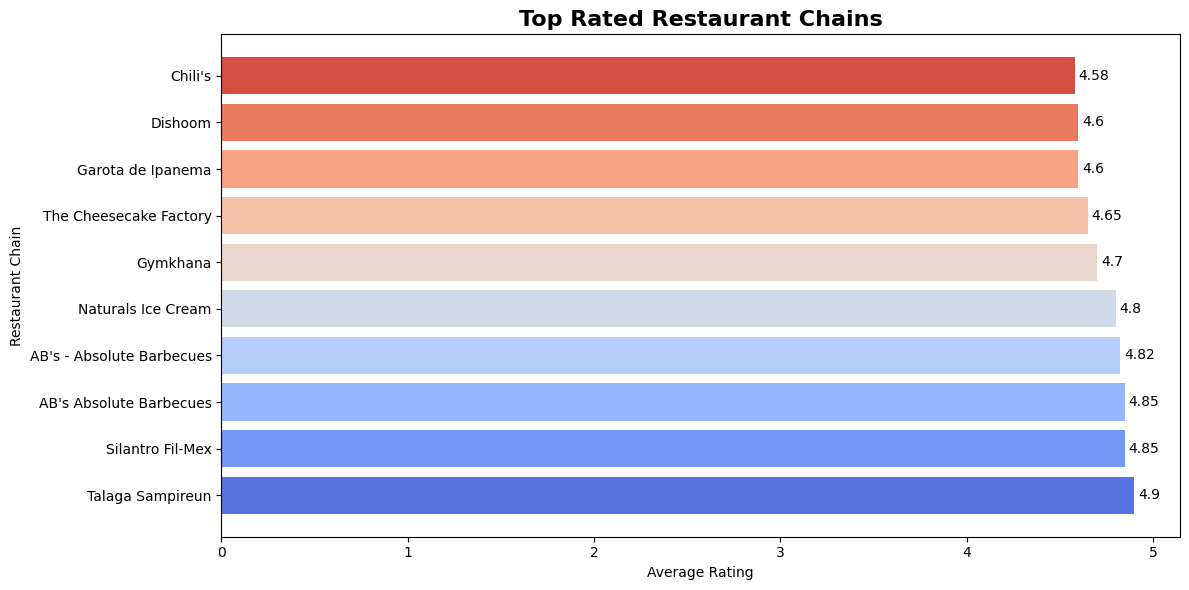

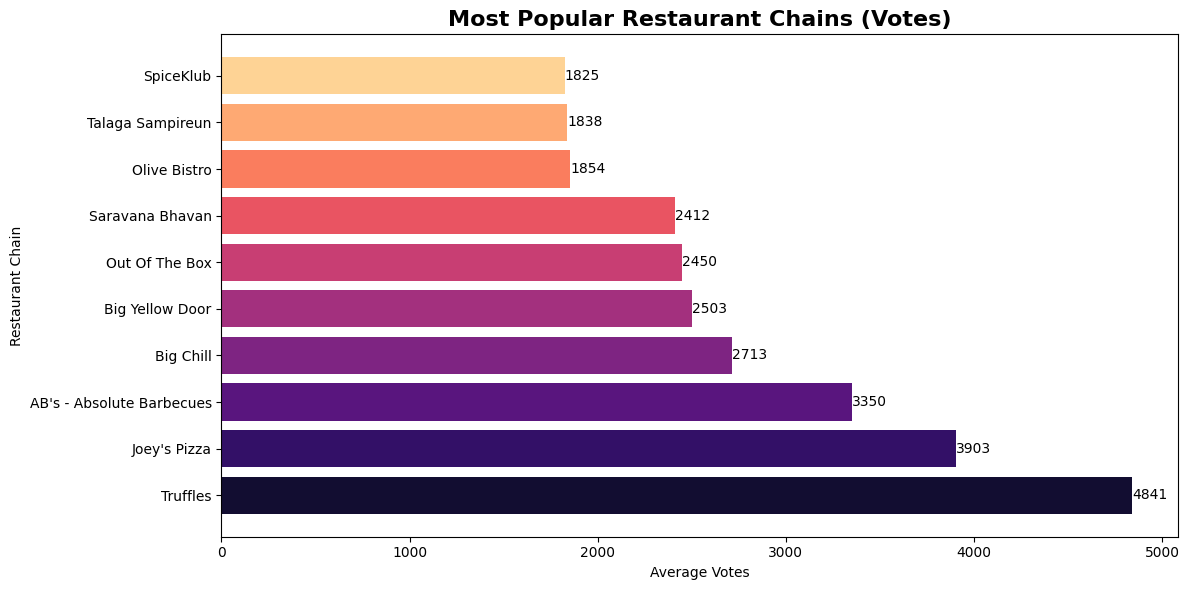

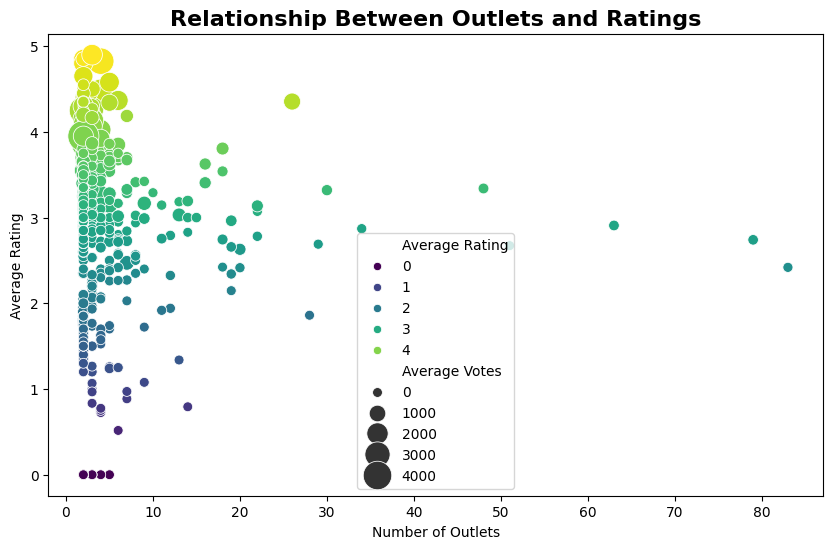


CONCLUSION

1. Total restaurant chains identified: 734

2. Largest chain:
   Cafe Coffee Day
   (83 outlets)

3. Highest rated chain:
   Talaga Sampireun
   Rating: 4.9

4. Most popular chain:
   Truffles
   Average Votes: 4841

5. Some chains maintain high ratings across multiple outlets.

6. Popular chains generally receive more customer votes, indicating higher customer engagement.

7. A larger number of outlets does not always guarantee higher ratings.


In [1]:
# ==========================================================
# Cognifyz Data Analysis Internship
# Level 2 - Task 4: Restaurant Chains Analysis
# ==========================================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------
# Load Dataset
# ----------------------------------------------------------

df = pd.read_csv(r"D:\2 Year iv sem\Python\Cognifyz-Data-Analysis\Dataset .csv")

print("="*60)
print("RESTAURANT CHAINS ANALYSIS")
print("="*60)

# ----------------------------------------------------------
# Identify Restaurant Chains
# ----------------------------------------------------------

restaurant_counts = df['Restaurant Name'].value_counts()

chains = restaurant_counts[restaurant_counts > 1]

print("\nNumber of Restaurant Chains:", len(chains))

print("\nTop 10 Restaurant Chains:")
print(chains.head(10))

# ----------------------------------------------------------
# Chain Statistics
# ----------------------------------------------------------

chain_data = df[df['Restaurant Name'].isin(chains.index)]

chain_analysis = chain_data.groupby('Restaurant Name').agg({
    'Aggregate rating':'mean',
    'Votes':'mean',
    'Restaurant ID':'count'
}).reset_index()

chain_analysis.columns = [
    'Restaurant Chain',
    'Average Rating',
    'Average Votes',
    'Number of Outlets'
]

# ----------------------------------------------------------
# Top Chains by Number of Outlets
# ----------------------------------------------------------

top_outlets = chain_analysis.sort_values(
    by='Number of Outlets',
    ascending=False
).head(10)

print("\nTop Chains by Number of Outlets:")
print(top_outlets)

# ----------------------------------------------------------
# Top Rated Chains
# ----------------------------------------------------------

top_rated = chain_analysis.sort_values(
    by='Average Rating',
    ascending=False
).head(10)

print("\nTop Rated Chains:")
print(top_rated)

# ----------------------------------------------------------
# Most Popular Chains (Votes)
# ----------------------------------------------------------

top_popular = chain_analysis.sort_values(
    by='Average Votes',
    ascending=False
).head(10)

print("\nMost Popular Chains:")
print(top_popular)

# ==========================================================
# Visualization 1
# Top Chains by Number of Outlets
# ==========================================================

plt.figure(figsize=(12,6))

colors = sns.color_palette("viridis", len(top_outlets))

bars = plt.bar(
    top_outlets['Restaurant Chain'],
    top_outlets['Number of Outlets'],
    color=colors
)

plt.title(
    "Top Restaurant Chains by Number of Outlets",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Restaurant Chain")
plt.ylabel("Number of Outlets")

plt.xticks(rotation=45)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center'
    )

plt.tight_layout()
plt.show()

# ==========================================================
# Visualization 2
# Top Rated Chains
# ==========================================================

plt.figure(figsize=(12,6))

bars = plt.barh(
    top_rated['Restaurant Chain'],
    top_rated['Average Rating'],
    color=sns.color_palette("coolwarm", len(top_rated))
)

plt.title(
    "Top Rated Restaurant Chains",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Average Rating")
plt.ylabel("Restaurant Chain")

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.02,
        bar.get_y()+bar.get_height()/2,
        round(width,2),
        va='center'
    )

plt.tight_layout()
plt.show()

# ==========================================================
# Visualization 3
# Most Popular Chains
# ==========================================================

plt.figure(figsize=(12,6))

bars = plt.barh(
    top_popular['Restaurant Chain'],
    top_popular['Average Votes'],
    color=sns.color_palette("magma", len(top_popular))
)

plt.title(
    "Most Popular Restaurant Chains (Votes)",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Average Votes")
plt.ylabel("Restaurant Chain")

for bar in bars:
    width = bar.get_width()

    plt.text(
        width,
        bar.get_y()+bar.get_height()/2,
        int(width),
        va='center'
    )

plt.tight_layout()
plt.show()

# ==========================================================
# Correlation Analysis
# ==========================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=chain_analysis,
    x='Number of Outlets',
    y='Average Rating',
    size='Average Votes',
    hue='Average Rating',
    palette='viridis',
    sizes=(50,500)
)

plt.title(
    "Relationship Between Outlets and Ratings",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Number of Outlets")
plt.ylabel("Average Rating")

plt.show()

# ==========================================================
# Conclusion
# ==========================================================

best_chain = top_rated.iloc[0]
popular_chain = top_popular.iloc[0]
largest_chain = top_outlets.iloc[0]

print("\n" + "="*60)
print("CONCLUSION")
print("="*60)

print(f"\n1. Total restaurant chains identified: {len(chains)}")

print(
    f"\n2. Largest chain:"
    f"\n   {largest_chain['Restaurant Chain']}"
    f"\n   ({largest_chain['Number of Outlets']} outlets)"
)

print(
    f"\n3. Highest rated chain:"
    f"\n   {best_chain['Restaurant Chain']}"
    f"\n   Rating: {round(best_chain['Average Rating'],2)}"
)

print(
    f"\n4. Most popular chain:"
    f"\n   {popular_chain['Restaurant Chain']}"
    f"\n   Average Votes: {int(popular_chain['Average Votes'])}"
)

print(
    "\n5. Some chains maintain high ratings across multiple outlets."
)

print(
    "\n6. Popular chains generally receive more customer votes, indicating higher customer engagement."
)

print(
    "\n7. A larger number of outlets does not always guarantee higher ratings."
)